<a href="https://colab.research.google.com/github/Zafar488/Portfolio/blob/main/MaaHifazat_FetalWatch_5_Source_Industry_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MaaHifazat AI — FetalWatch Model

## Industry-Level Five-Source Fetal Monitoring Workflow

This notebook develops **Model 2: FetalWatch**, whose deployed tabular head predicts:

- `Normal`
- `Suspicious`
- `Pathological`

### Five verified real-world data sources

| Source | Data | Valid role in this workflow |
|---|---|---|
| UCI Cardiotocography | 2,126 CTGs, 21 features, expert `NSP` labels | Main supervised 3-class training |
| CTU-UHB | 552 intrapartum FHR/UC recordings with pH, Apgar and outcomes | Outcome-based external validation |
| FHRMA | 135 FHR recordings with expert morphology annotations | Morphology/feature-extractor auxiliary learning |
| SPaM CTG Challenge 2017 | 297 long CTG recordings | Self-supervised pretraining; manual DUA access |
| NInFEA | 60 multimodal recordings from 39 healthy pregnancies | Healthy-domain robustness evaluation |

## Scientific rule

These datasets are **not blindly concatenated with invented labels**. Only UCI provides the same direct three-class fetal-state target. The other four sources are integrated through a shared signal-feature bank, auxiliary learning and external validation.

This prevents:

- fabricated `Normal/Suspicious/Pathological` labels;
- outcome leakage;
- duplicate-source leakage;
- unrealistically high test accuracy;
- mixing antepartum and intrapartum populations without tracking provenance.

> **Clinical notice:** This is a research and hackathon prototype. It is not a medical device and cannot replace obstetric or neonatal clinical judgment.

## 1. Install packages

In [1]:
%%capture
!pip install -U \
    "pandas>=2.0" \
    "numpy>=1.24" \
    "scipy>=1.10" \
    "matplotlib>=3.7" \
    "scikit-learn>=1.4,<2.0" \
    "imbalanced-learn>=0.12" \
    "xgboost>=2.0,<4.0" \
    "lightgbm>=4.0" \
    "ucimlrepo>=0.0.7" \
    "wfdb>=4.1" \
    "requests>=2.31" \
    "joblib>=1.3" \
    "pyarrow>=15.0" \
    "fastapi>=0.110" \
    "uvicorn>=0.27" \
    "pydantic>=2.6"

## 2. Imports, configuration and reproducibility

`FAST_MODE=True` keeps the first Colab run manageable. Set it to `False` for the final deeper search.

In [1]:
from __future__ import annotations

import hashlib
import io
import json
import math
import os
import platform
import random
import re
import shutil
import sys
import tarfile
import warnings
import zipfile
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import sklearn
import wfdb
import xgboost
import lightgbm

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from scipy.signal import find_peaks
from scipy.stats import randint, loguniform, uniform
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedGroupKFold,
    cross_val_predict,
    cross_validate,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelBinarizer, RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
FAST_MODE = True
SEARCH_ITERATIONS = 15 if FAST_MODE else 50
CV_SPLITS = 5
TARGET_PATHOLOGICAL_RECALL = 0.92
MODEL_VERSION = "1.0.0"

# Optional raw-signal processing can download hundreds of MB.
RUN_AUXILIARY_SIGNAL_STAGE = False
MAX_RECORDS_PER_AUXILIARY_SOURCE = 30 if FAST_MODE else None

np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/fetalwatch_project")
RAW_DIR = ROOT / "raw"
PROCESSED_DIR = ROOT / "processed"
ARTIFACT_DIR = ROOT / "artifacts"
AUX_DIR = ROOT / "auxiliary_sources"

for folder in [RAW_DIR, PROCESSED_DIR, ARTIFACT_DIR, AUX_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("Project root:", ROOT)

Python: 3.12.13
scikit-learn: 1.9.0
XGBoost: 3.3.0
LightGBM: 4.6.0
Project root: /content/fetalwatch_project


## 3. Portable CTG feature-engineering module

The transformer is written to a real Python file so the exported `joblib` model can later be loaded by FastAPI and LangGraph without pickle errors.

In [2]:
%%writefile fetalwatch_features.py
from __future__ import annotations

from typing import Dict

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

RAW_FEATURES = [
    "LB", "AC", "FM", "UC", "DL", "DS", "DP",
    "ASTV", "MSTV", "ALTV", "MLTV",
    "Width", "Min", "Max", "Nmax", "Nzeros",
    "Mode", "Mean", "Median", "Variance", "Tendency",
]

SANITY_BOUNDS = {
    "LB": (50.0, 220.0),
    "AC": (0.0, 1.0),
    "FM": (0.0, 1.0),
    "UC": (0.0, 1.0),
    "DL": (0.0, 1.0),
    "DS": (0.0, 1.0),
    "DP": (0.0, 1.0),
    "ASTV": (0.0, 100.0),
    "MSTV": (0.0, 20.0),
    "ALTV": (0.0, 100.0),
    "MLTV": (0.0, 100.0),
    "Width": (0.0, 250.0),
    "Min": (30.0, 240.0),
    "Max": (50.0, 260.0),
    "Nmax": (0.0, 50.0),
    "Nzeros": (0.0, 50.0),
    "Mode": (30.0, 240.0),
    "Mean": (30.0, 240.0),
    "Median": (30.0, 240.0),
    "Variance": (0.0, 500.0),
    "Tendency": (-1.0, 1.0),
}


class FetalCTGFeatureEngineer(BaseEstimator, TransformerMixin):
    """Create continuous morphology and variability features."""

    def __init__(self, include_interactions: bool = True):
        self.include_interactions = include_interactions

    def fit(self, X, y=None):
        frame = self._to_frame(X)
        self.feature_names_in_ = np.asarray(frame.columns, dtype=object)
        return self

    def transform(self, X):
        frame = self._to_frame(X).astype(float).copy()
        eps = 1e-8

        frame["TotalDecelerationRate"] = (
            frame["DL"] + frame["DS"] + frame["DP"]
        )
        frame["SevereDecelerationBurden"] = (
            frame["DS"] + 2.0 * frame["DP"]
        )
        frame["AccelerationDecelerationBalance"] = (
            frame["AC"] - frame["TotalDecelerationRate"]
        )
        frame["ActivityRate"] = frame["FM"] + frame["UC"]
        frame["AccelerationToContractionRatio"] = (
            frame["AC"] / (frame["UC"].abs() + eps)
        )
        frame["DecelerationToContractionRatio"] = (
            frame["TotalDecelerationRate"]
            / (frame["UC"].abs() + eps)
        )
        frame["VariabilityComposite"] = (
            frame["MSTV"] + frame["MLTV"]
        )
        frame["AbnormalVariabilityBurden"] = (
            frame["ASTV"] + frame["ALTV"]
        )
        frame["HistogramRangeCheck"] = frame["Max"] - frame["Min"]
        frame["CenterSpread"] = (
            (frame["Mean"] - frame["Median"]).abs()
            + (frame["Median"] - frame["Mode"]).abs()
        )
        frame["BaselineMeanDifference"] = frame["LB"] - frame["Mean"]
        frame["BaselineMedianDifference"] = frame["LB"] - frame["Median"]
        frame["VarianceLog1p"] = np.log1p(frame["Variance"].clip(lower=0))
        frame["PeakDensityProxy"] = (
            frame["Nmax"] / (frame["Width"].abs() + eps)
        )
        frame["ZeroPeakRatio"] = (
            frame["Nzeros"] / (frame["Nmax"].abs() + 1.0)
        )

        if self.include_interactions:
            frame["ASTV_MSTV_Interaction"] = (
                frame["ASTV"] * frame["MSTV"]
            )
            frame["ALTV_MLTV_Interaction"] = (
                frame["ALTV"] * frame["MLTV"]
            )
            frame["BaselineVariabilityInteraction"] = (
                frame["LB"] * frame["VariabilityComposite"]
            )
            frame["DecelerationVarianceInteraction"] = (
                frame["TotalDecelerationRate"]
                * frame["VarianceLog1p"]
            )

        return frame

    def get_feature_names_out(self, input_features=None):
        base = list(RAW_FEATURES)
        engineered = [
            "TotalDecelerationRate",
            "SevereDecelerationBurden",
            "AccelerationDecelerationBalance",
            "ActivityRate",
            "AccelerationToContractionRatio",
            "DecelerationToContractionRatio",
            "VariabilityComposite",
            "AbnormalVariabilityBurden",
            "HistogramRangeCheck",
            "CenterSpread",
            "BaselineMeanDifference",
            "BaselineMedianDifference",
            "VarianceLog1p",
            "PeakDensityProxy",
            "ZeroPeakRatio",
        ]
        if self.include_interactions:
            engineered += [
                "ASTV_MSTV_Interaction",
                "ALTV_MLTV_Interaction",
                "BaselineVariabilityInteraction",
                "DecelerationVarianceInteraction",
            ]
        return np.asarray(base + engineered, dtype=object)

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            missing = [c for c in RAW_FEATURES if c not in X.columns]
            if missing:
                raise ValueError(f"Missing CTG columns: {missing}")
            return X.loc[:, RAW_FEATURES].copy()

        array = np.asarray(X)
        if array.ndim != 2 or array.shape[1] != len(RAW_FEATURES):
            raise ValueError(
                f"Expected a 2-D array with {len(RAW_FEATURES)} columns."
            )
        return pd.DataFrame(array, columns=RAW_FEATURES)


def validate_ctg_input(
    frame: pd.DataFrame,
    *,
    strict: bool = True,
) -> Dict[str, list]:
    issues = {
        "missing_columns": [],
        "missing_values": [],
        "out_of_bounds": [],
    }

    missing_columns = [c for c in RAW_FEATURES if c not in frame.columns]
    issues["missing_columns"] = missing_columns

    if missing_columns:
        if strict:
            raise ValueError(f"Missing columns: {missing_columns}")
        return issues

    numeric = frame[RAW_FEATURES].apply(pd.to_numeric, errors="coerce")

    for column, count in numeric.isna().sum().items():
        if count:
            issues["missing_values"].append({
                "column": column,
                "count": int(count),
            })

    for column, (lower, upper) in SANITY_BOUNDS.items():
        mask = numeric[column].notna() & ~numeric[column].between(
            lower, upper, inclusive="both"
        )
        if mask.any():
            issues["out_of_bounds"].append({
                "column": column,
                "count": int(mask.sum()),
                "allowed": [lower, upper],
                "examples": numeric.loc[mask, column].head(5).tolist(),
            })

    if strict and (
        issues["missing_values"] or issues["out_of_bounds"]
    ):
        raise ValueError(f"Input validation failed: {issues}")

    return issues

Writing fetalwatch_features.py


In [3]:
from fetalwatch_features import (
    FetalCTGFeatureEngineer,
    RAW_FEATURES,
    SANITY_BOUNDS,
    validate_ctg_input,
)

print("Raw CTG features:", len(RAW_FEATURES))

Raw CTG features: 21


## 4. Load the official UCI Cardiotocography dataset

The target loader supports both numeric `1/2/3` codes and textual `N/S/P` values.

In [4]:
from ucimlrepo import fetch_ucirepo

def load_uci_ctg() -> tuple[pd.DataFrame, pd.Series]:
    dataset = fetch_ucirepo(id=193)
    features = dataset.data.features.copy()
    targets = dataset.data.targets.copy()

    if isinstance(targets, pd.Series):
        target_raw = targets
    elif "NSP" in targets.columns:
        target_raw = targets["NSP"]
    else:
        possible = [
            column for column in targets.columns
            if str(column).strip().upper() == "NSP"
        ]
        if not possible:
            raise ValueError(
                f"NSP target not found. Available targets: {targets.columns.tolist()}"
            )
        target_raw = targets[possible[0]]

    features.columns = [str(c).strip() for c in features.columns]

    missing = [c for c in RAW_FEATURES if c not in features.columns]
    if missing:
        raise ValueError(f"UCI feature schema mismatch: {missing}")

    features = features[RAW_FEATURES].apply(
        pd.to_numeric,
        errors="coerce",
    )

    normalized = target_raw.astype(str).str.strip().str.lower()

    label_map = {
        "1": 0, "n": 0, "normal": 0,
        "2": 1, "s": 1, "suspect": 1, "suspicious": 1,
        "3": 2, "p": 2, "pathologic": 2, "pathological": 2,
    }

    target = normalized.map(label_map)
    if target.isna().any():
        bad = normalized[target.isna()].unique().tolist()
        raise ValueError(f"Unmapped NSP values: {bad}")

    target = target.astype(int)
    return features.reset_index(drop=True), target.reset_index(drop=True)

X_raw, y = load_uci_ctg()

ID_TO_LABEL = {
    0: "normal",
    1: "suspicious",
    2: "pathological",
}
LABEL_TO_ID = {value: key for key, value in ID_TO_LABEL.items()}
PATHOLOGICAL_ID = 2

print("Shape:", X_raw.shape)
display(X_raw.head())
display(
    y.map(ID_TO_LABEL)
    .value_counts()
    .rename_axis("fetal_state")
    .to_frame("count")
)

Shape: (2126, 21)


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,64,62,126,2,0,120,137,121,73,1
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,130,68,198,6,1,141,136,140,12,0
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,130,68,198,5,1,141,135,138,13,0
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,117,53,170,11,0,137,134,137,13,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,117,53,170,9,0,137,136,138,11,1


,count
fetal_state,
normal,1655
suspicious,295
pathological,176


## 5. Data-quality, duplicate and conflict analysis

The UCI table can contain repeated feature signatures. A group ID is generated from all 21 raw features so identical CTG signatures cannot cross train/test or CV boundaries.

In [5]:
quality_report = {
    "rows": int(len(X_raw)),
    "features": int(X_raw.shape[1]),
    "missing_values": X_raw.isna().sum().astype(int).to_dict(),
    "validation_issues": validate_ctg_input(X_raw, strict=False),
    "exact_duplicate_feature_rows": int(X_raw.duplicated().sum()),
}

row_signature = pd.util.hash_pandas_object(
    X_raw.round(10),
    index=False,
).astype(str)

signature_label_counts = (
    pd.DataFrame({
        "signature": row_signature,
        "target": y,
    })
    .groupby("signature")["target"]
    .nunique()
)

quality_report["unique_signatures"] = int(row_signature.nunique())
quality_report["conflicting_signatures"] = int(
    (signature_label_counts > 1).sum()
)

print(json.dumps(quality_report, indent=2))

{
  "rows": 2126,
  "features": 21,
  "missing_values": {
    "LB": 0,
    "AC": 0,
    "FM": 0,
    "UC": 0,
    "DL": 0,
    "DS": 0,
    "DP": 0,
    "ASTV": 0,
    "MSTV": 0,
    "ALTV": 0,
    "MLTV": 0,
    "Width": 0,
    "Min": 0,
    "Max": 0,
    "Nmax": 0,
    "Nzeros": 0,
    "Mode": 0,
    "Mean": 0,
    "Median": 0,
    "Variance": 0,
    "Tendency": 0
  },
  "validation_issues": {
    "missing_columns": [],
    "missing_values": [],
    "out_of_bounds": []
  },
  "exact_duplicate_feature_rows": 15,
  "unique_signatures": 2111,
  "conflicting_signatures": 2
}


## 6. Exploratory data analysis

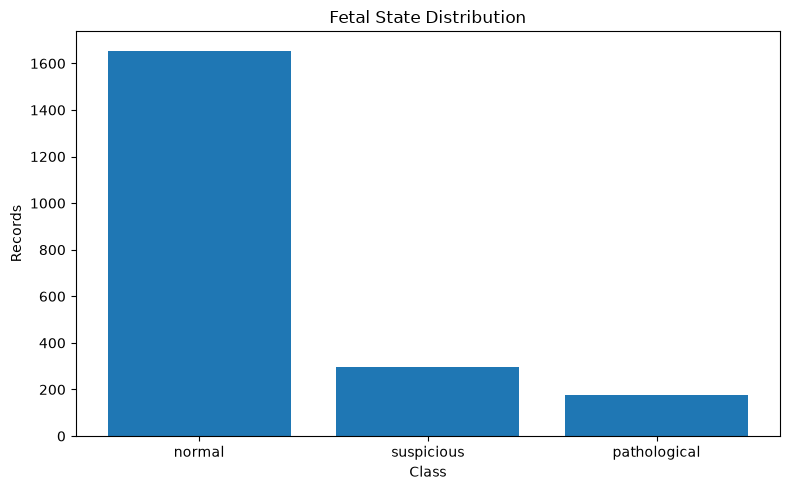

In [6]:
class_counts = y.map(ID_TO_LABEL).value_counts().reindex(
    ["normal", "suspicious", "pathological"]
)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Fetal State Distribution")
plt.xlabel("Class")
plt.ylabel("Records")
plt.tight_layout()
plt.show()

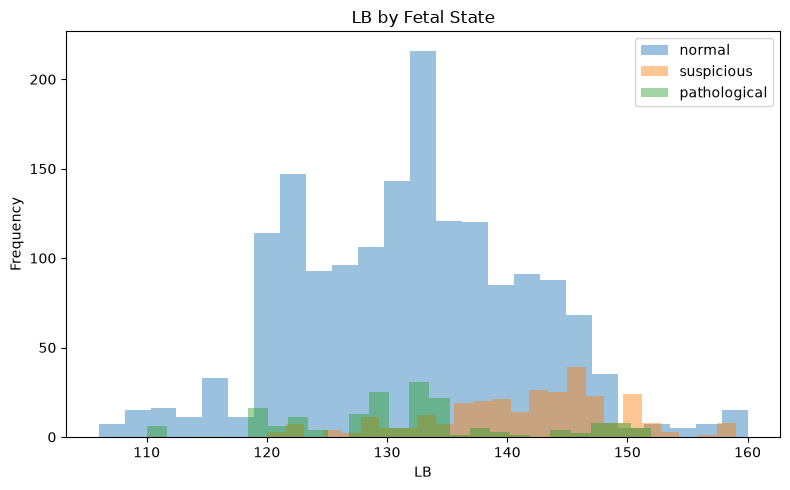

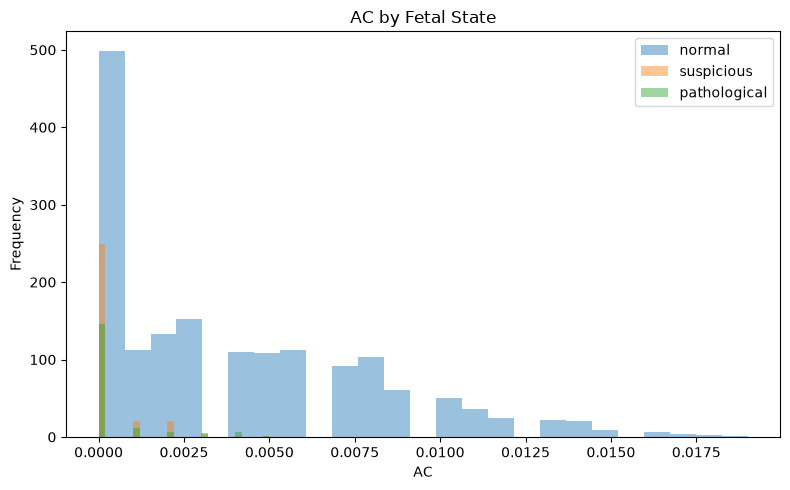

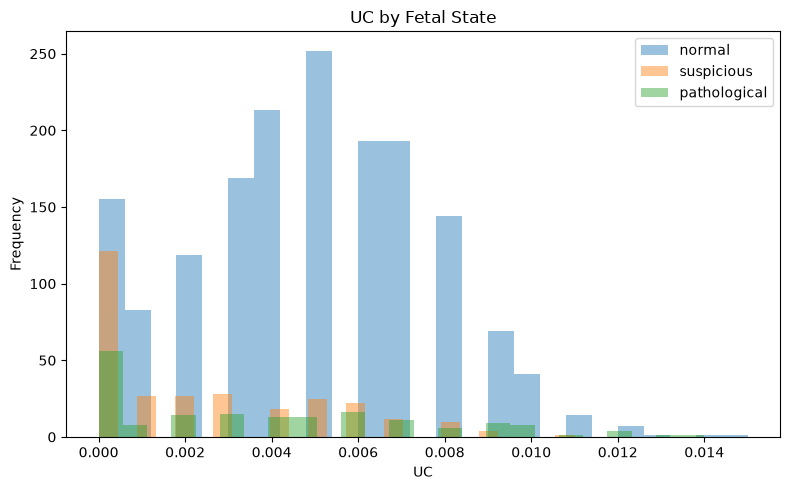

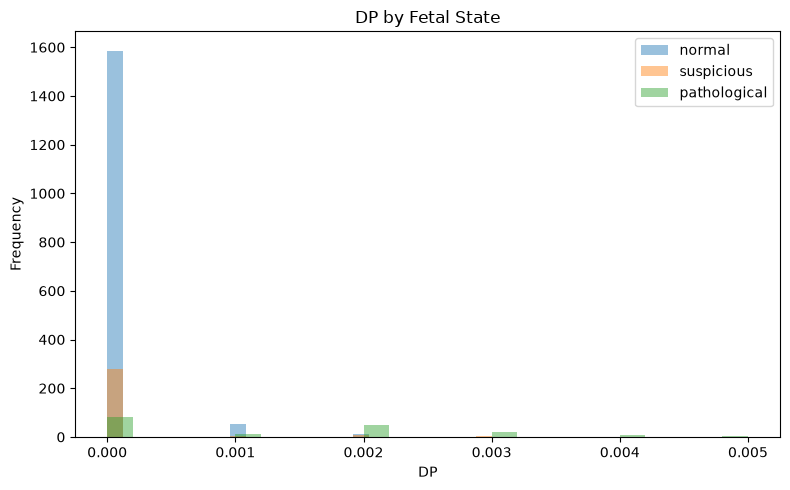

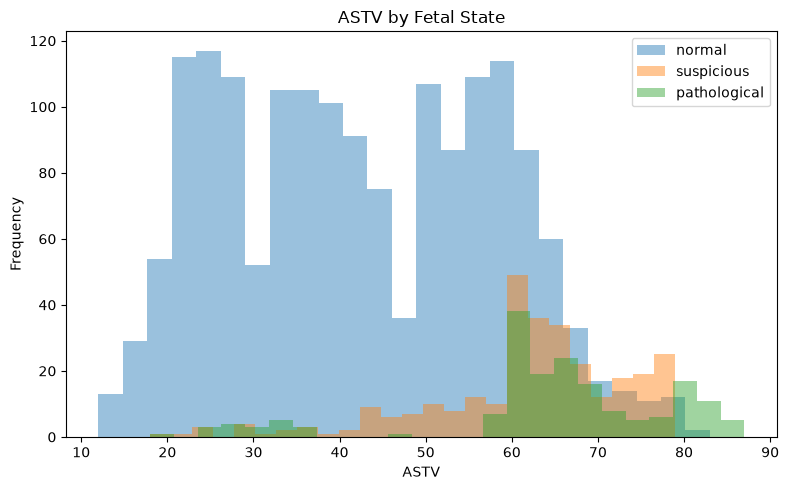

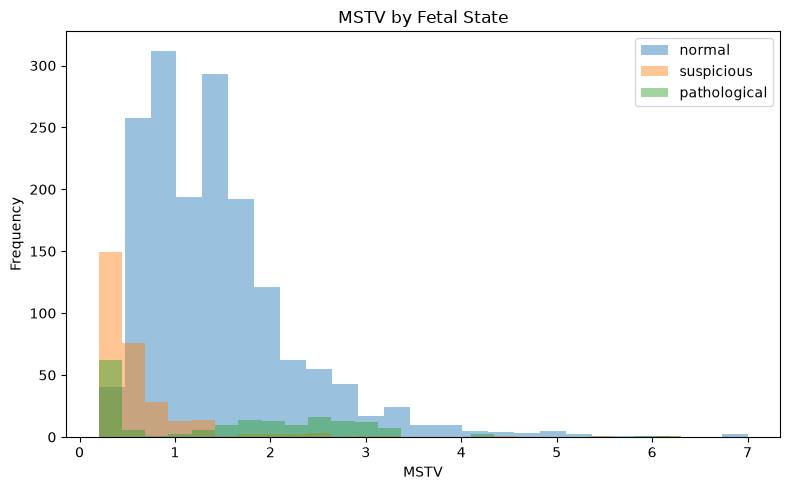

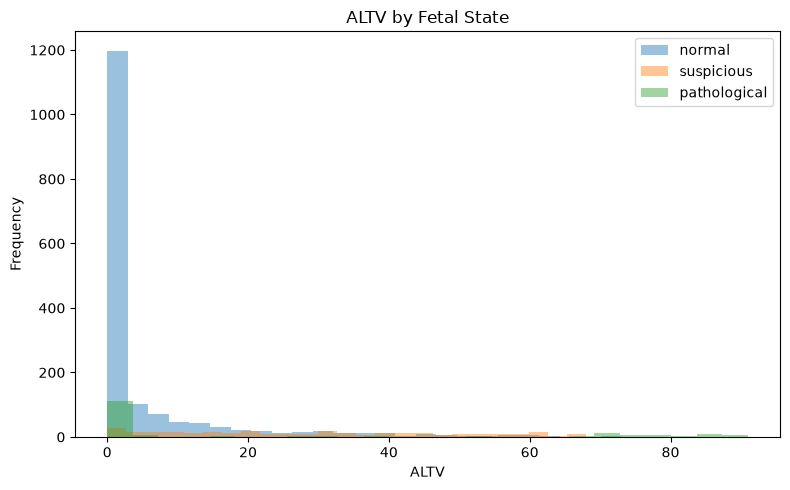

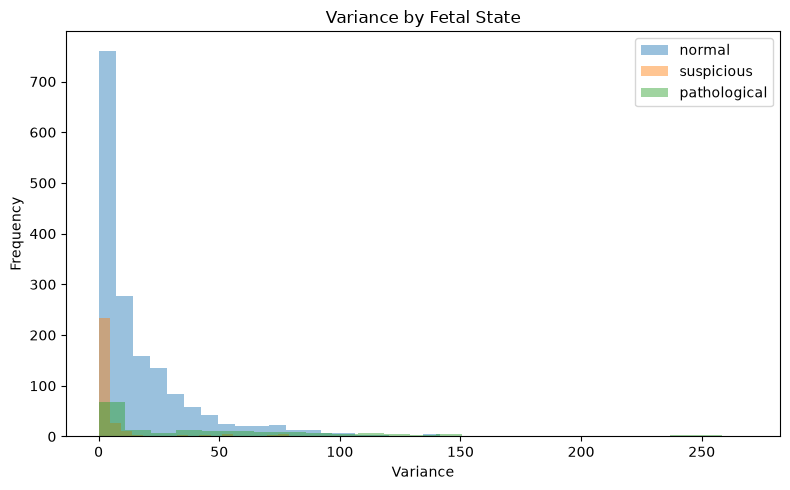

In [7]:
for feature in ["LB", "AC", "UC", "DP", "ASTV", "MSTV", "ALTV", "Variance"]:
    plt.figure(figsize=(8, 5))
    for class_id, class_name in ID_TO_LABEL.items():
        values = X_raw.loc[y == class_id, feature].dropna()
        plt.hist(values, bins=25, alpha=0.45, label=class_name)
    plt.title(f"{feature} by Fetal State")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Group-safe held-out test split

The held-out test fold is never used for model comparison, tuning, threshold selection or calibration.

In [8]:
outer_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

train_idx, test_idx = next(
    outer_splitter.split(
        X_raw,
        y,
        groups=row_signature,
    )
)

X_train = X_raw.iloc[train_idx].reset_index(drop=True)
X_test = X_raw.iloc[test_idx].reset_index(drop=True)
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)
groups_train = row_signature.iloc[train_idx].reset_index(drop=True)
groups_test = row_signature.iloc[test_idx].reset_index(drop=True)

assert set(groups_train).isdisjoint(set(groups_test))
assert set(y_train.unique()) == {0, 1, 2}
assert set(y_test.unique()) == {0, 1, 2}

split_summary = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
split_summary.index = split_summary.index.map(ID_TO_LABEL)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
display(split_summary)

Training rows: 1701
Test rows: 425


,train,test
NSP,,
normal,1324,331
suspicious,236,59
pathological,141,35


## 8. Leakage-safe preprocessing and four requested algorithms

Algorithms:

1. Random Forest  
2. XGBoost  
3. LightGBM  
4. Multilayer Perceptron  

Random oversampling for the MLP happens **inside each training fold**, not before splitting.

In [13]:
tree_preprocessor = Pipeline([
    (
        "feature_engineering",
        FetalCTGFeatureEngineer(include_interactions=True),
    ),
    (
        "imputer",
        SimpleImputer(strategy="median", add_indicator=True),
    ),
])

neural_preprocessor_steps = [
    (
        "feature_engineering",
        FetalCTGFeatureEngineer(include_interactions=True),
    ),
    (
        "imputer",
        SimpleImputer(strategy="median", add_indicator=True),
    ),
    ("scaler", RobustScaler()),
]

candidate_models = {
    "random_forest": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=600,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=1,
        )),
    ]),
    "xgboost": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBClassifier(
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            n_estimators=450,
            max_depth=4,
            learning_rate=0.04,
            min_child_weight=2,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.01,
            reg_lambda=3.0,
            random_state=SEED,
            tree_method="hist",
            n_jobs=1,
        )),
    ]),
    "lightgbm": Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=450,
            learning_rate=0.04,
            num_leaves=31,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
            verbosity=-1,
        )),
    ]),
    "multilayer_perceptron": ImbPipeline(neural_preprocessor_steps + [
        ("oversample", RandomOverSampler(random_state=SEED)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(96, 48),
            activation="relu",
            alpha=1e-3,
            learning_rate_init=1e-3,
            early_stopping=True,
            validation_fraction=0.15,
            max_iter=500,
            random_state=SEED,
        )),
    ]),
}

print(list(candidate_models))

['random_forest', 'xgboost', 'lightgbm', 'multilayer_perceptron']


## 9. Safety-focused scoring

Model selection emphasizes **pathological recall**, because missing a pathological case is the most serious model error.

In [10]:
from sklearn.metrics import make_scorer

def pathological_recall(y_true, y_pred) -> float:
    return recall_score(
        y_true,
        y_pred,
        labels=[PATHOLOGICAL_ID],
        average="macro",
        zero_division=0,
    )

def pathological_precision(y_true, y_pred) -> float:
    return precision_score(
        y_true,
        y_pred,
        labels=[PATHOLOGICAL_ID],
        average="macro",
        zero_division=0,
    )

def safety_score(y_true, y_pred) -> float:
    path_recall = pathological_recall(y_true, y_pred)
    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    return 0.60 * path_recall + 0.40 * macro_f1

SCORING = {
    "safety": make_scorer(safety_score),
    "macro_f1": make_scorer(
        f1_score,
        average="macro",
        zero_division=0,
    ),
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "pathological_recall": make_scorer(pathological_recall),
    "pathological_precision": make_scorer(pathological_precision),
}

inner_cv = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)

## 10. Cross-validated benchmark

In [14]:
benchmark_rows = []

for model_name, estimator in candidate_models.items():
    print("Evaluating:", model_name)

    result = cross_validate(
        estimator=estimator,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=inner_cv,
        scoring=SCORING,
        n_jobs=-1,
        error_score="raise",
    )

    benchmark_rows.append({
        "model": model_name,
        "mean_safety": result["test_safety"].mean(),
        "std_safety": result["test_safety"].std(),
        "mean_macro_f1": result["test_macro_f1"].mean(),
        "mean_balanced_accuracy": (
            result["test_balanced_accuracy"].mean()
        ),
        "mean_pathological_recall": (
            result["test_pathological_recall"].mean()
        ),
        "mean_pathological_precision": (
            result["test_pathological_precision"].mean()
        ),
        "mean_fit_seconds": result["fit_time"].mean(),
    })

benchmark = (
    pd.DataFrame(benchmark_rows)
    .sort_values("mean_safety", ascending=False)
    .reset_index(drop=True)
)

display(benchmark.round(4))
benchmark.to_csv(
    ARTIFACT_DIR / "baseline_model_benchmark.csv",
    index=False,
)


Evaluating: random_forest
Evaluating: xgboost
Evaluating: lightgbm
Evaluating: multilayer_perceptron


,model,mean_safety,std_safety,mean_macro_f1,mean_balanced_accuracy,mean_pathological_recall,mean_pathological_precision,mean_fit_seconds
0,lightgbm,0.9117,0.0422,0.9184,0.9143,0.9071,0.9159,3.3592
1,xgboost,0.8876,0.0869,0.9012,0.8853,0.8786,0.9191,1.9312
2,random_forest,0.8727,0.0514,0.8843,0.8723,0.8650,0.9265,5.0091
3,multilayer_perceptron,0.8502,0.0486,0.8380,0.8681,0.8584,0.8647,2.3732


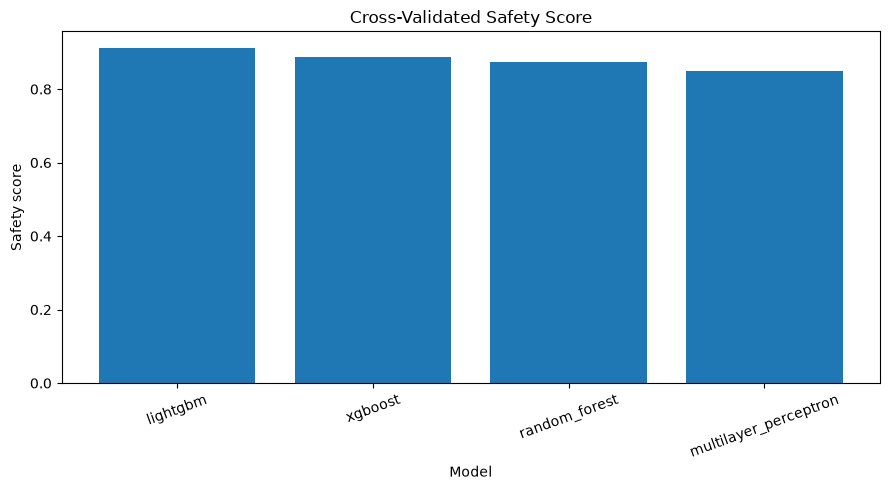

In [15]:
plt.figure(figsize=(9, 5))
plt.bar(benchmark["model"], benchmark["mean_safety"])
plt.title("Cross-Validated Safety Score")
plt.xlabel("Model")
plt.ylabel("Safety score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 11. Hyperparameter tuning of the best model family

In [16]:
best_family = benchmark.iloc[0]["model"]
search_estimator = clone(candidate_models[best_family])

PARAMETER_SPACES = {
    "random_forest": {
        "model__n_estimators": randint(350, 1100),
        "model__max_depth": [None, 5, 8, 12, 16, 24],
        "model__min_samples_split": randint(2, 18),
        "model__min_samples_leaf": randint(1, 8),
        "model__max_features": ["sqrt", "log2", 0.6, 0.8, None],
        "model__class_weight": [
            "balanced",
            "balanced_subsample",
        ],
    },
    "xgboost": {
        "model__n_estimators": randint(250, 1000),
        "model__max_depth": randint(2, 9),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__min_child_weight": randint(1, 10),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
        "model__gamma": uniform(0.0, 1.0),
    },
    "lightgbm": {
        "model__n_estimators": randint(250, 1000),
        "model__learning_rate": loguniform(0.01, 0.20),
        "model__num_leaves": randint(15, 96),
        "model__max_depth": [-1, 4, 6, 8, 12, 16],
        "model__min_child_samples": randint(10, 80),
        "model__subsample": uniform(0.65, 0.35),
        "model__colsample_bytree": uniform(0.65, 0.35),
        "model__reg_alpha": loguniform(1e-5, 2.0),
        "model__reg_lambda": loguniform(0.1, 15.0),
    },
    "multilayer_perceptron": {
        "model__hidden_layer_sizes": [
            (64,), (96,), (128,), (96, 48), (128, 64), (128, 64, 32),
        ],
        "model__alpha": loguniform(1e-5, 1e-1),
        "model__learning_rate_init": loguniform(1e-4, 5e-3),
        "model__activation": ["relu", "tanh"],
    },
}

search = RandomizedSearchCV(
    estimator=search_estimator,
    param_distributions=PARAMETER_SPACES[best_family],
    n_iter=SEARCH_ITERATIONS,
    scoring=SCORING,
    refit="safety",
    cv=inner_cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise",
)

search.fit(
    X_train,
    y_train,
    groups=groups_train,
)

best_estimator = search.best_estimator_

print("Selected family:", best_family)
print("Best CV safety score:", round(search.best_score_, 4))
print(json.dumps(search.best_params_, indent=2, default=str))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Selected family: lightgbm
Best CV safety score: 0.9177
{
  "model__colsample_bytree": 0.6905541708337954,
  "model__learning_rate": 0.1327160497040489,
  "model__max_depth": 8,
  "model__min_child_samples": 43,
  "model__n_estimators": 282,
  "model__num_leaves": 62,
  "model__reg_alpha": 0.0009240993778227332,
  "model__reg_lambda": 2.8540370300201316,
  "model__subsample": 0.8830728248161238
}


In [17]:
search_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("rank_test_safety")
)

display(
    search_results[[
        "rank_test_safety",
        "mean_test_safety",
        "mean_test_macro_f1",
        "mean_test_balanced_accuracy",
        "mean_test_pathological_recall",
        "mean_test_pathological_precision",
        "mean_train_safety",
        "params",
    ]].head(10)
)

search_results.to_csv(
    ARTIFACT_DIR / "hyperparameter_search_results.csv",
    index=False,
)

,rank_test_safety,mean_test_safety,mean_test_macro_f1,mean_test_balanced_accuracy,mean_test_pathological_recall,mean_test_pathological_precision,mean_train_safety,params
10,1,0.917689,0.922795,0.924393,0.914286,0.909041,0.999668,{'model__colsample_bytree': 0.6905541708337954...
13,2,0.904697,0.911743,0.911841,0.900000,0.913305,0.999668,{'model__colsample_bytree': 0.8471464501917343...
0,3,0.902814,0.907034,0.904811,0.900000,0.906843,0.999668,{'model__colsample_bytree': 0.7810890415965769...
8,4,0.902128,0.916035,0.911224,0.892857,0.913681,0.999668,{'model__colsample_bytree': 0.9878393575424482...
3,5,0.900541,0.912066,0.914634,0.892857,0.899436,0.999337,{'model__colsample_bytree': 0.6817122520864873...
11,6,0.899664,0.909874,0.913849,0.892857,0.899752,0.998926,{'model__colsample_bytree': 0.8569542256977045...
7,7,0.898437,0.906807,0.916310,0.892857,0.887114,0.995909,{'model__colsample_bytree': 0.6809723757181718...
12,8,0.897020,0.903265,0.905559,0.892857,0.886740,0.999668,{'model__colsample_bytree': 0.9198385129840964...
5,9,0.895003,0.908936,0.908752,0.885714,0.891968,0.999668,{'model__colsample_bytree': 0.8891422315889104...
6,10,0.892600,0.902928,0.908759,0.885714,0.904279,0.998189,{'model__colsample_bytree': 0.7146990594339345...


## 12. Out-of-fold pathological threshold optimization

The threshold is selected only from out-of-fold training predictions.

In [18]:
oof_probabilities = cross_val_predict(
    estimator=clone(best_estimator),
    X=X_train,
    y=y_train,
    groups=groups_train,
    cv=inner_cv,
    method="predict_proba",
    n_jobs=-1,
)

def apply_pathological_threshold(
    probabilities: np.ndarray,
    threshold: float,
) -> np.ndarray:
    predictions = np.argmax(probabilities, axis=1).astype(int)
    predictions[
        probabilities[:, PATHOLOGICAL_ID] >= threshold
    ] = PATHOLOGICAL_ID
    return predictions

threshold_rows = []

for threshold in np.round(np.arange(0.10, 0.81, 0.01), 2):
    predictions = apply_pathological_threshold(
        oof_probabilities,
        threshold,
    )

    threshold_rows.append({
        "threshold": float(threshold),
        "pathological_recall": pathological_recall(
            y_train,
            predictions,
        ),
        "pathological_precision": pathological_precision(
            y_train,
            predictions,
        ),
        "macro_f1": f1_score(
            y_train,
            predictions,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_train,
            predictions,
        ),
    })

threshold_table = pd.DataFrame(threshold_rows)

eligible = threshold_table[
    threshold_table["pathological_recall"]
    >= TARGET_PATHOLOGICAL_RECALL
].copy()

if len(eligible):
    selected_threshold_row = eligible.sort_values(
        ["macro_f1", "pathological_precision", "threshold"],
        ascending=[False, False, False],
    ).iloc[0]
else:
    threshold_table["fallback_score"] = (
        0.70 * threshold_table["pathological_recall"]
        + 0.30 * threshold_table["macro_f1"]
    )
    selected_threshold_row = threshold_table.sort_values(
        "fallback_score",
        ascending=False,
    ).iloc[0]

PATHOLOGICAL_THRESHOLD = float(
    selected_threshold_row["threshold"]
)

print("Selected threshold:", PATHOLOGICAL_THRESHOLD)
display(selected_threshold_row.to_frame("value"))

threshold_table.to_csv(
    ARTIFACT_DIR / "pathological_threshold_analysis.csv",
    index=False,
)

Selected threshold: 0.35


,value
threshold,0.350000
pathological_recall,0.921986
pathological_precision,0.902778
macro_f1,0.923114
balanced_accuracy,0.925482


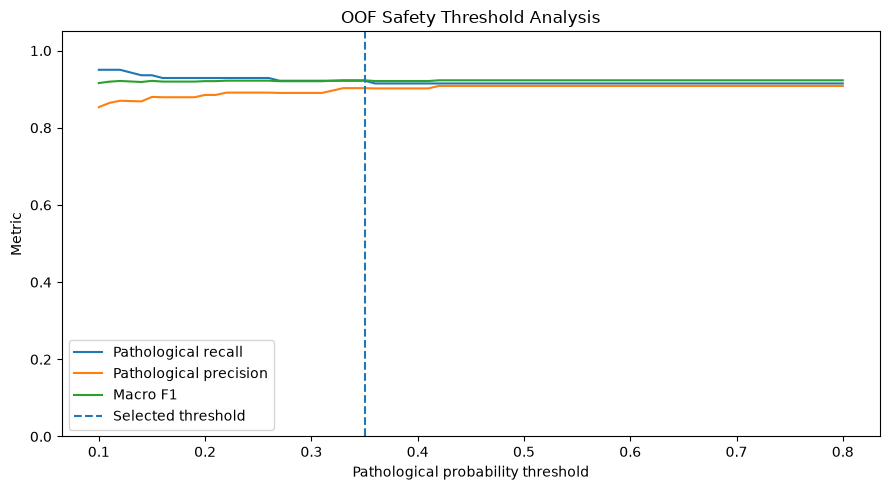

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(
    threshold_table["threshold"],
    threshold_table["pathological_recall"],
    label="Pathological recall",
)
plt.plot(
    threshold_table["threshold"],
    threshold_table["pathological_precision"],
    label="Pathological precision",
)
plt.plot(
    threshold_table["threshold"],
    threshold_table["macro_f1"],
    label="Macro F1",
)
plt.axvline(
    PATHOLOGICAL_THRESHOLD,
    linestyle="--",
    label="Selected threshold",
)
plt.xlabel("Pathological probability threshold")
plt.ylabel("Metric")
plt.ylim(0, 1.05)
plt.title("OOF Safety Threshold Analysis")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Fit tuned model and calibrate probabilities

In [20]:
decision_model = clone(best_estimator).fit(X_train, y_train)

calibration_splits = list(
    inner_cv.split(
        X_train,
        y_train,
        groups=groups_train,
    )
)

probability_model = CalibratedClassifierCV(
    estimator=clone(best_estimator),
    method="sigmoid",
    cv=calibration_splits,
    ensemble=True,
    n_jobs=-1,
)
probability_model.fit(X_train, y_train)

print("Decision and calibrated probability models fitted.")

Decision and calibrated probability models fitted.


## 14. Final held-out test evaluation

Report:

- Macro F1
- Balanced accuracy
- Pathological recall
- Confusion matrix
- One-vs-rest ROC-AUC
- Log loss

In [21]:
raw_test_probabilities = decision_model.predict_proba(X_test)
calibrated_test_probabilities = probability_model.predict_proba(X_test)

test_predictions = apply_pathological_threshold(
    raw_test_probabilities,
    PATHOLOGICAL_THRESHOLD,
)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(
        y_test,
        test_predictions,
    ),
    "macro_f1": f1_score(
        y_test,
        test_predictions,
        average="macro",
        zero_division=0,
    ),
    "weighted_f1": f1_score(
        y_test,
        test_predictions,
        average="weighted",
        zero_division=0,
    ),
    "pathological_recall": pathological_recall(
        y_test,
        test_predictions,
    ),
    "pathological_precision": pathological_precision(
        y_test,
        test_predictions,
    ),
    "roc_auc_ovr_macro": roc_auc_score(
        y_test,
        calibrated_test_probabilities,
        labels=[0, 1, 2],
        multi_class="ovr",
        average="macro",
    ),
    "log_loss": log_loss(
        y_test,
        calibrated_test_probabilities,
        labels=[0, 1, 2],
    ),
}

print(json.dumps(test_metrics, indent=2))
print()
print(classification_report(
    y_test,
    test_predictions,
    labels=[0, 1, 2],
    target_names=[
        ID_TO_LABEL[0],
        ID_TO_LABEL[1],
        ID_TO_LABEL[2],
    ],
    zero_division=0,
))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

{
  "accuracy": 0.9552941176470588,
  "balanced_accuracy": 0.9305652887403105,
  "macro_f1": 0.9179913287160707,
  "weighted_f1": 0.9553301636473658,
  "pathological_recall": 0.9714285714285714,
  "pathological_precision": 0.8292682926829268,
  "roc_auc_ovr_macro": 0.9931494625470427,
  "log_loss": 0.14718986817324375
}

              precision    recall  f1-score   support

      normal       0.98      0.97      0.97       331
  suspicious       0.93      0.85      0.88        59
pathological       0.83      0.97      0.89        35

    accuracy                           0.96       425
   macro avg       0.91      0.93      0.92       425
weighted avg       0.96      0.96      0.96       425



<Figure size 700x600 with 0 Axes>

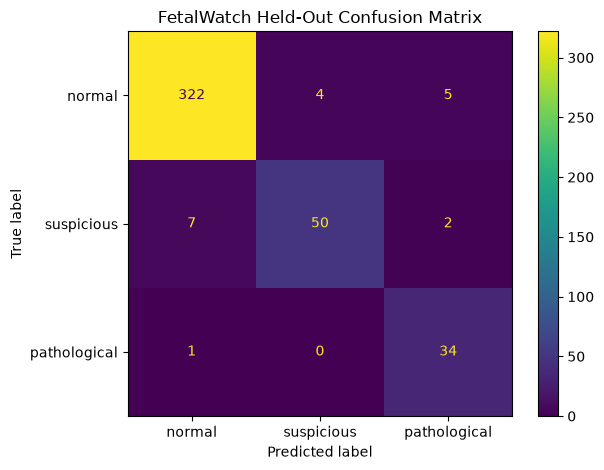

In [22]:
plt.figure(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1, 2],
    display_labels=[
        ID_TO_LABEL[0],
        ID_TO_LABEL[1],
        ID_TO_LABEL[2],
    ],
    values_format="d",
)
plt.title("FetalWatch Held-Out Confusion Matrix")
plt.tight_layout()
plt.show()

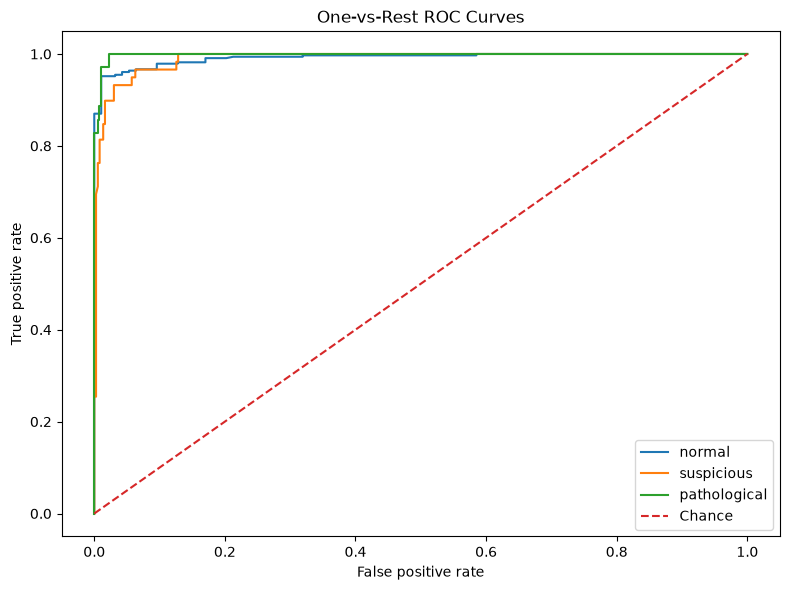

In [23]:
label_binarizer = LabelBinarizer().fit([0, 1, 2])
y_test_binary = label_binarizer.transform(y_test)

plt.figure(figsize=(8, 6))

for class_id, class_name in ID_TO_LABEL.items():
    fpr, tpr, _ = roc_curve(
        y_test_binary[:, class_id],
        calibrated_test_probabilities[:, class_id],
    )
    plt.plot(fpr, tpr, label=class_name)

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.title("One-vs-Rest ROC Curves")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.show()

## 15. Pathological probability calibration

<Figure size 800x600 with 0 Axes>

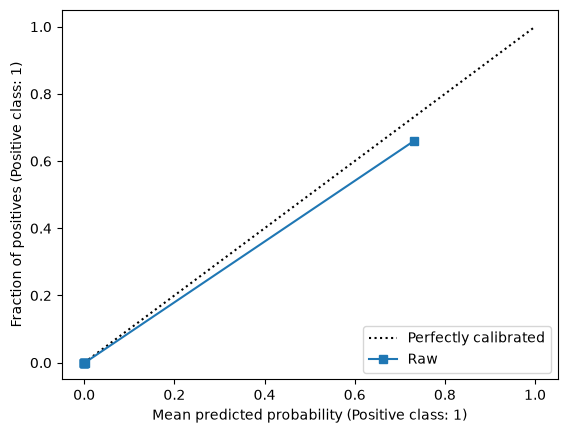

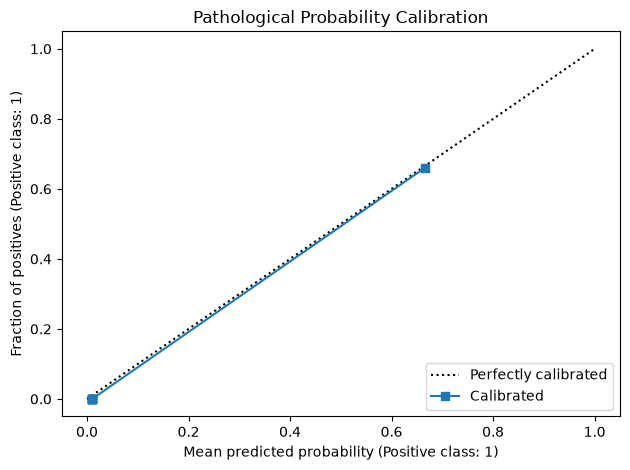

In [24]:
pathological_binary = (
    y_test.to_numpy() == PATHOLOGICAL_ID
).astype(int)

plt.figure(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    pathological_binary,
    raw_test_probabilities[:, PATHOLOGICAL_ID],
    n_bins=8,
    strategy="quantile",
    name="Raw",
)
CalibrationDisplay.from_predictions(
    pathological_binary,
    calibrated_test_probabilities[:, PATHOLOGICAL_ID],
    n_bins=8,
    strategy="quantile",
    name="Calibrated",
)
plt.title("Pathological Probability Calibration")
plt.tight_layout()
plt.show()

## 16. Permutation importance and error analysis

In [25]:
importance = permutation_importance(
    estimator=decision_model,
    X=X_test,
    y=y_test,
    scoring=make_scorer(safety_score),
    n_repeats=20 if FAST_MODE else 50,
    random_state=SEED,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "feature": RAW_FEATURES,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance_df.round(4))
importance_df.to_csv(
    ARTIFACT_DIR / "permutation_importance.csv",
    index=False,
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,feature,importance_mean,importance_std
0,ALTV,0.2295,0.0153
1,Median,0.2002,0.0401
2,ASTV,0.1259,0.0144
3,AC,0.0521,0.0102
4,Mean,0.0401,0.0157
5,MSTV,0.0368,0.0107
6,LB,0.0275,0.0127
7,DP,0.0173,0.0051
8,UC,0.0165,0.0166
9,MLTV,0.0049,0.0075


In [26]:
error_analysis = X_test.copy()
error_analysis["true_class"] = y_test.map(ID_TO_LABEL)
error_analysis["predicted_class"] = pd.Series(
    test_predictions
).map(ID_TO_LABEL)
error_analysis["pathological_probability_raw"] = (
    raw_test_probabilities[:, PATHOLOGICAL_ID]
)
error_analysis["pathological_probability_calibrated"] = (
    calibrated_test_probabilities[:, PATHOLOGICAL_ID]
)
error_analysis["correct"] = (
    y_test.to_numpy() == test_predictions
)
error_analysis["critical_false_negative"] = (
    (y_test.to_numpy() == PATHOLOGICAL_ID)
    & (test_predictions != PATHOLOGICAL_ID)
)

error_analysis = error_analysis.sort_values(
    ["critical_false_negative", "correct", "pathological_probability_raw"],
    ascending=[False, True, True],
)

print(
    "Critical pathological false negatives:",
    int(error_analysis["critical_false_negative"].sum()),
)
display(error_analysis.head(30))

error_analysis.to_csv(
    ARTIFACT_DIR / "heldout_error_analysis.csv",
    index=False,
)

Critical pathological false negatives: 1


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Mean,Median,Variance,Tendency,true_class,predicted_class,pathological_probability_raw,pathological_probability_calibrated,correct,critical_false_negative
387,140,0.000,0.008,0.006,0.002,0.000,0.003,62,2.4,2,...,123,130,11,1,pathological,normal,1.977819e-01,0.187657,False,True
81,141,0.005,0.023,0.002,0.001,0.000,0.000,53,1.0,28,...,149,154,10,1,suspicious,normal,7.156169e-06,0.009648,False,False
13,138,0.001,0.000,0.004,0.000,0.000,0.000,44,1.0,20,...,156,159,8,1,normal,suspicious,1.318845e-05,0.009943,False,False
84,150,0.000,0.000,0.000,0.003,0.000,0.000,47,1.1,15,...,154,157,8,1,normal,suspicious,7.907750e-05,0.010176,False,False
159,146,0.000,0.000,0.001,0.000,0.000,0.000,53,0.5,32,...,156,158,2,1,normal,suspicious,1.086402e-04,0.010147,False,False
275,144,0.000,0.000,0.008,0.001,0.000,0.000,60,0.4,8,...,145,148,2,1,suspicious,normal,1.476794e-04,0.010067,False,False
58,142,0.000,0.005,0.000,0.000,0.000,0.000,57,0.8,32,...,142,144,3,1,normal,suspicious,5.403741e-04,0.010372,False,False
309,133,0.000,0.000,0.007,0.000,0.000,0.000,43,0.8,30,...,140,143,4,1,suspicious,normal,7.463582e-04,0.009819,False,False
90,143,0.000,0.000,0.002,0.000,0.000,0.000,65,0.5,0,...,143,145,1,0,suspicious,normal,1.036159e-03,0.009945,False,False
52,128,0.000,0.000,0.006,0.000,0.000,0.000,30,1.2,0,...,154,155,13,0,suspicious,normal,1.435453e-03,0.010326,False,False


# Part B — Five-source auxiliary signal integration

The next section creates a common provenance-aware signal feature bank.

## Source registry and access rules

- CTU-UHB is open through PhysioNet.
- FHRMA is available through CTGDL/GPL.
- SPaM requires its own Data Use Agreement and manual upload.
- NInFEA is open but large.
- UCI is already loaded above.

`RUN_AUXILIARY_SIGNAL_STAGE` is `False` by default to avoid large downloads during the first model run.

In [27]:
SOURCE_REGISTRY = {
    "uci_ctg": {
        "role": "supervised_3_class",
        "records": 2126,
        "access": "automatic",
        "license": "CC BY 4.0",
    },
    "ctu_uhb": {
        "role": "outcome_external_validation",
        "records": 552,
        "access": "PhysioNet open",
        "license": "ODC Attribution 1.0",
    },
    "fhrma": {
        "role": "morphology_auxiliary_learning",
        "records": 135,
        "access": "CTGDL / Zenodo",
        "license": "GPL-3.0",
    },
    "spam_2017": {
        "role": "self_supervised_pretraining",
        "records": 297,
        "access": "manual DUA",
        "license": "Data Use Agreement",
    },
    "ninfea": {
        "role": "healthy_domain_robustness",
        "records": 60,
        "participants": 39,
        "access": "PhysioNet open",
        "license": "ODC Attribution 1.0",
    },
}

display(pd.DataFrame(SOURCE_REGISTRY).T)

,role,records,access,license,participants
uci_ctg,supervised_3_class,2126,automatic,CC BY 4.0,NaN
ctu_uhb,outcome_external_validation,552,PhysioNet open,ODC Attribution 1.0,NaN
fhrma,morphology_auxiliary_learning,135,CTGDL / Zenodo,GPL-3.0,NaN
spam_2017,self_supervised_pretraining,297,manual DUA,Data Use Agreement,NaN
ninfea,healthy_domain_robustness,60,PhysioNet open,ODC Attribution 1.0,39


## 17. Download CTGDL metadata and inspect available files

The Zenodo API is used so the notebook does not hard-code expiring file links.

In [28]:
CTGDL_ZENODO_RECORD_ID = "19510407"

def get_zenodo_record(record_id: str) -> dict:
    url = f"https://zenodo.org/api/records/{record_id}"
    response = requests.get(url, timeout=90)
    response.raise_for_status()
    return response.json()

def zenodo_file_table(record: dict) -> pd.DataFrame:
    rows = []
    for item in record.get("files", []):
        rows.append({
            "name": item.get("key"),
            "size_mb": item.get("size", 0) / (1024 ** 2),
            "checksum": item.get("checksum"),
            "download_url": (
                item.get("links", {}).get("content")
                or item.get("links", {}).get("self")
            ),
        })
    return pd.DataFrame(rows)

ctgdl_record = get_zenodo_record(CTGDL_ZENODO_RECORD_ID)
ctgdl_files = zenodo_file_table(ctgdl_record)

display(ctgdl_files[["name", "size_mb", "checksum"]])

,name,size_mb,checksum
0,CTGDL_norm_metadata.csv,0.064256,md5:73b01cc118080fd6aa91e6d7d0e3ceab
1,CTGDL_FHRMA_proc_csv.tar.gz,6.723850,md5:6ba1f1f62db376b775c83531dea0d058
2,df_sig_1120.csv,0.437871,md5:e12304ce5e6478d5d32223170f7f6f73
3,CTGDL_FHEMA_metadata.csv,0.017752,md5:a748d260f55dab846c5f2f624beeafb9
4,CTGDL_SPAM_metadata.csv,0.032445,md5:8a4f153173ab77972dfb2e934f1044c8
5,CTGDL_FHRMA_ano_csv.tar.gz,45.982683,md5:3ab873dad96443583cf0c9c6fd73e70e
6,CTGDL_ctu_uhb_proc_csv.tar.gz,25.217927,md5:881aee257fbbddef00e113738a0299cc
7,CTGDL_ctu_uhb_csv.tar.gz,14.026294,md5:5ba245b3a23e4f67312419dbb25dbee6
8,CTGDL - Data Collection.pdf,0.563832,md5:1faeec195ad06bbfdb92c856ab60389d
9,CTGDL_spam_dataset_read_matlab_signal_and_prep...,5.801070,md5:4f8db4f1890e3a77bc44d04a4773584e


## 18. Generic downloader with checksum support

In [29]:
def download_file(
    url: str,
    output_path: Path,
    expected_md5: str | None = None,
) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        print("Already exists:", output_path)
        return output_path

    with requests.get(url, stream=True, timeout=300) as response:
        response.raise_for_status()
        with output_path.open("wb") as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)

    if expected_md5:
        digest = hashlib.md5(output_path.read_bytes()).hexdigest()
        if digest.lower() != expected_md5.lower():
            raise ValueError(
                f"Checksum mismatch for {output_path.name}: {digest}"
            )

    return output_path

## 19. Shared signal cleaning and feature extraction

This converts raw FHR/UC time series into a common engineered table. It is intended for auxiliary learning and external validation, not for pretending that all sources share UCI's target labels.

In [30]:
def clean_ctg_signal(
    fhr: np.ndarray,
    uc: np.ndarray | None,
    sampling_rate: float = 4.0,
) -> tuple[np.ndarray, np.ndarray]:
    fhr = np.asarray(fhr, dtype=float).reshape(-1)
    if uc is None:
        uc = np.full_like(fhr, np.nan)
    else:
        uc = np.asarray(uc, dtype=float).reshape(-1)

    length = min(len(fhr), len(uc))
    fhr = fhr[:length]
    uc = uc[:length]

    fhr[(fhr < 50) | (fhr > 220)] = np.nan
    uc[(uc < 0) | (uc > 200)] = np.nan

    fhr_series = pd.Series(fhr)
    max_gap = max(1, int(15 * sampling_rate))
    fhr = (
        fhr_series
        .interpolate(limit=max_gap, limit_direction="both")
        .to_numpy()
    )

    uc = (
        pd.Series(uc)
        .interpolate(limit=max_gap, limit_direction="both")
        .to_numpy()
    )

    return fhr, uc

def count_events(
    signal: np.ndarray,
    baseline: np.ndarray,
    threshold_bpm: float,
    minimum_seconds: float,
    sampling_rate: float,
    direction: str,
) -> tuple[int, float]:
    if direction == "up":
        event_mask = signal - baseline >= threshold_bpm
    else:
        event_mask = baseline - signal >= threshold_bpm

    event_mask = np.nan_to_num(event_mask.astype(float), nan=0.0).astype(bool)
    padded = np.r_[False, event_mask, False]
    changes = np.diff(padded.astype(int))
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    minimum_samples = int(minimum_seconds * sampling_rate)
    durations = ends - starts
    valid = durations >= minimum_samples

    event_count = int(valid.sum())
    burden_seconds = float(durations[valid].sum() / sampling_rate)
    return event_count, burden_seconds

def extract_signal_features(
    fhr: np.ndarray,
    uc: np.ndarray | None,
    sampling_rate: float,
) -> dict:
    fhr, uc = clean_ctg_signal(fhr, uc, sampling_rate)

    valid_fhr = np.isfinite(fhr)
    valid_uc = np.isfinite(uc)

    if valid_fhr.mean() < 0.50:
        raise ValueError("FHR signal quality below 50%.")

    fhr_filled = pd.Series(fhr).interpolate().bfill().ffill().to_numpy()
    window = max(3, int(60 * sampling_rate))
    baseline = (
        pd.Series(fhr_filled)
        .rolling(window=window, center=True, min_periods=1)
        .median()
        .to_numpy()
    )

    acceleration_count, acceleration_burden = count_events(
        fhr_filled,
        baseline,
        threshold_bpm=15,
        minimum_seconds=15,
        sampling_rate=sampling_rate,
        direction="up",
    )
    deceleration_count, deceleration_burden = count_events(
        fhr_filled,
        baseline,
        threshold_bpm=15,
        minimum_seconds=15,
        sampling_rate=sampling_rate,
        direction="down",
    )

    fhr_diff = np.diff(fhr_filled)
    rmssd = float(np.sqrt(np.mean(np.square(fhr_diff)))) if len(fhr_diff) else np.nan

    uc_filled = pd.Series(uc).interpolate().bfill().ffill().fillna(0).to_numpy()
    uc_prominence = max(5.0, float(np.nanstd(uc_filled)))
    contraction_peaks, _ = find_peaks(
        uc_filled,
        distance=max(1, int(60 * sampling_rate)),
        prominence=uc_prominence,
    )

    p05, p25, p50, p75, p95 = np.percentile(
        fhr_filled,
        [5, 25, 50, 75, 95],
    )

    return {
        "duration_minutes": len(fhr_filled) / sampling_rate / 60,
        "fhr_quality": float(valid_fhr.mean()),
        "uc_quality": float(valid_uc.mean()),
        "fhr_mean": float(np.mean(fhr_filled)),
        "fhr_median": float(np.median(fhr_filled)),
        "fhr_std": float(np.std(fhr_filled)),
        "fhr_min": float(np.min(fhr_filled)),
        "fhr_max": float(np.max(fhr_filled)),
        "fhr_p05": float(p05),
        "fhr_p25": float(p25),
        "fhr_p75": float(p75),
        "fhr_p95": float(p95),
        "fhr_iqr": float(p75 - p25),
        "fhr_range_90": float(p95 - p05),
        "rmssd": rmssd,
        "baseline_mean": float(np.mean(baseline)),
        "acceleration_count": acceleration_count,
        "acceleration_burden_seconds": acceleration_burden,
        "deceleration_count": deceleration_count,
        "deceleration_burden_seconds": deceleration_burden,
        "contraction_count": int(len(contraction_peaks)),
        "uc_mean": float(np.mean(uc_filled)),
        "uc_std": float(np.std(uc_filled)),
        "missing_feature_count": int(
            np.isnan([
                np.mean(fhr_filled),
                rmssd,
                np.mean(uc_filled),
            ]).sum()
        ),
    }

## 20. CTU-UHB processor

The outcome target is kept separate from the UCI three-class state. `pH < 7.15` is stored as an acidemia endpoint for external evaluation only.

In [31]:
def parse_header_comments(comments: Iterable[str]) -> dict:
    metadata = {}
    for comment in comments or []:
        if ":" in comment:
            key, value = comment.split(":", 1)
            metadata[
                re.sub(r"[^a-z0-9]+", "_", key.strip().lower()).strip("_")
            ] = value.strip()
    return metadata

def process_ctu_uhb_records(
    max_records: int | None = None,
) -> pd.DataFrame:
    records_text = requests.get(
        "https://physionet.org/files/ctu-uhb-ctgdb/1.0.0/RECORDS",
        timeout=60,
    )
    records_text.raise_for_status()
    record_names = [
        line.strip()
        for line in records_text.text.splitlines()
        if line.strip()
    ]

    if max_records:
        record_names = record_names[:max_records]

    rows = []

    for index, record_name in enumerate(record_names, start=1):
        try:
            record = wfdb.rdrecord(
                record_name,
                pn_dir="ctu-uhb-ctgdb/1.0.0",
            )
            signal = record.p_signal
            channel_names = [name.lower() for name in record.sig_name]

            fhr_index = next(
                i for i, name in enumerate(channel_names)
                if "fhr" in name
            )
            uc_index = next(
                (
                    i for i, name in enumerate(channel_names)
                    if "uc" in name
                ),
                None,
            )

            fhr = signal[:, fhr_index]
            uc = signal[:, uc_index] if uc_index is not None else None

            features = extract_signal_features(
                fhr,
                uc,
                sampling_rate=float(record.fs),
            )

            metadata = parse_header_comments(record.comments)
            ph_value = None
            for key, value in metadata.items():
                if key in {"p_h", "ph", "ph_art", "ph_arterial"}:
                    match = re.search(r"[-+]?\d*\.?\d+", value)
                    if match:
                        ph_value = float(match.group())
                        break

            features.update({
                "dataset_source": "ctu_uhb",
                "record_id": record_name,
                "sampling_rate": float(record.fs),
                "umbilical_artery_ph": ph_value,
                "acidemia_ph_lt_7_15": (
                    int(ph_value < 7.15)
                    if ph_value is not None
                    else np.nan
                ),
                "three_class_target": np.nan,
                "dataset_role": "external_outcome_validation",
            })
            rows.append(features)

        except Exception as error:
            print("Skipped", record_name, "->", repr(error))

        if index % 25 == 0:
            print("Processed", index, "records")

    return pd.DataFrame(rows)

## 21. Manual source folders for FHRMA and SPaM

- FHRMA can be downloaded from CTGDL.
- SPaM must be obtained under its DUA and uploaded to Colab.
- The generic loader expects CSV files with identifiable FHR and optional UC columns.

Edit aliases if a file uses different column names.

In [32]:
FHR_COLUMN_ALIASES = [
    "fhr", "fetal_heart_rate", "fetalheartrate", "heart_rate",
]
UC_COLUMN_ALIASES = [
    "uc", "uterine_contraction", "uterinecontractions", "toco",
]

def normalized_column_map(frame: pd.DataFrame) -> dict:
    return {
        re.sub(r"[^a-z0-9]+", "", str(column).lower()): column
        for column in frame.columns
    }

def find_alias_column(
    frame: pd.DataFrame,
    aliases: list[str],
) -> str | None:
    normalized = normalized_column_map(frame)
    for alias in aliases:
        key = re.sub(r"[^a-z0-9]+", "", alias.lower())
        if key in normalized:
            return normalized[key]
    return None

def process_signal_csv_folder(
    folder: Path,
    source_name: str,
    sampling_rate: float = 4.0,
    max_records: int | None = None,
) -> pd.DataFrame:
    files = sorted(folder.rglob("*.csv"))
    if max_records:
        files = files[:max_records]

    rows = []

    for file_path in files:
        try:
            frame = pd.read_csv(file_path, low_memory=False)
            fhr_col = find_alias_column(frame, FHR_COLUMN_ALIASES)
            uc_col = find_alias_column(frame, UC_COLUMN_ALIASES)

            if fhr_col is None:
                continue

            fhr = pd.to_numeric(frame[fhr_col], errors="coerce").to_numpy()
            uc = (
                pd.to_numeric(frame[uc_col], errors="coerce").to_numpy()
                if uc_col is not None
                else None
            )

            features = extract_signal_features(
                fhr,
                uc,
                sampling_rate=sampling_rate,
            )
            features.update({
                "dataset_source": source_name,
                "record_id": file_path.stem,
                "sampling_rate": sampling_rate,
                "three_class_target": np.nan,
                "dataset_role": (
                    "morphology_auxiliary"
                    if source_name == "fhrma"
                    else "self_supervised_pretraining"
                ),
            })
            rows.append(features)

        except Exception as error:
            print("Skipped", file_path.name, "->", repr(error))

    return pd.DataFrame(rows)

## 22. NInFEA registry and healthy-domain rule

NInFEA contains fetal ECG/Doppler rather than standard dual-channel CTG, and all fetuses were screened as healthy. It is therefore stored as an external healthy-domain source, not assigned fabricated UCI features.

In [33]:
def load_ninfea_registry() -> pd.DataFrame:
    records_url = "https://physionet.org/files/ninfea/1.0.0/RECORDS"
    response = requests.get(records_url, timeout=60)
    response.raise_for_status()

    records = [
        line.strip()
        for line in response.text.splitlines()
        if line.strip()
    ]

    return pd.DataFrame({
        "dataset_source": "ninfea",
        "record_id": records,
        "dataset_role": "healthy_domain_robustness",
        "known_healthy_fetus": 1,
        "three_class_target": np.nan,
    })

ninfea_registry = load_ninfea_registry()
display(ninfea_registry.head())
print("NInFEA entries:", len(ninfea_registry))

,dataset_source,record_id,dataset_role,known_healthy_fetus,three_class_target
0,ninfea,wfdb_format_ecg_and_respiration/1,healthy_domain_robustness,1,NaN
1,ninfea,wfdb_format_ecg_and_respiration/2,healthy_domain_robustness,1,NaN
2,ninfea,wfdb_format_ecg_and_respiration/3,healthy_domain_robustness,1,NaN
3,ninfea,wfdb_format_ecg_and_respiration/4,healthy_domain_robustness,1,NaN
4,ninfea,wfdb_format_ecg_and_respiration/5,healthy_domain_robustness,1,NaN


NInFEA entries: 60


## 23. Build the optional five-source feature bank

Before running:

1. Set `RUN_AUXILIARY_SIGNAL_STAGE=True`.
2. Put processed FHRMA CSVs in `AUX_DIR / "fhrma"`.
3. Put licensed SPaM CSVs in `AUX_DIR / "spam_2017"`.
4. CTU-UHB will be read directly from PhysioNet.

In [34]:
auxiliary_tables = []

if RUN_AUXILIARY_SIGNAL_STAGE:
    ctu_features = process_ctu_uhb_records(
        max_records=MAX_RECORDS_PER_AUXILIARY_SOURCE,
    )
    auxiliary_tables.append(ctu_features)

    fhrma_folder = AUX_DIR / "fhrma"
    if fhrma_folder.exists():
        fhrma_features = process_signal_csv_folder(
            folder=fhrma_folder,
            source_name="fhrma",
            sampling_rate=4.0,
            max_records=MAX_RECORDS_PER_AUXILIARY_SOURCE,
        )
        auxiliary_tables.append(fhrma_features)

    spam_folder = AUX_DIR / "spam_2017"
    if spam_folder.exists():
        spam_features = process_signal_csv_folder(
            folder=spam_folder,
            source_name="spam_2017",
            sampling_rate=4.0,
            max_records=MAX_RECORDS_PER_AUXILIARY_SOURCE,
        )
        auxiliary_tables.append(spam_features)

    if auxiliary_tables:
        auxiliary_feature_bank = pd.concat(
            auxiliary_tables,
            ignore_index=True,
            sort=False,
        )
        auxiliary_feature_bank.to_parquet(
            PROCESSED_DIR / "auxiliary_signal_feature_bank.parquet",
            index=False,
        )
        display(auxiliary_feature_bank.head())
        display(
            auxiliary_feature_bank["dataset_source"]
            .value_counts()
            .to_frame("records")
        )
    else:
        print("No auxiliary signal table was created.")
else:
    print(
        "Auxiliary signal stage is disabled. "
        "The complete UCI three-class workflow still runs."
    )

Auxiliary signal stage is disabled. The complete UCI three-class workflow still runs.


## 24. External CTU-UHB pathological-probability validation

This section does **not** call acidemia a UCI pathological label. It checks whether the model's pathological probability is associated with the independent pH outcome after a clinician-approved feature bridge is available.

A feature bridge must convert signal-derived features into the exact 21 UCI feature definitions. The notebook intentionally does not fake this conversion.

In [35]:
FEATURE_BRIDGE_REQUIRED = True

if RUN_AUXILIARY_SIGNAL_STAGE and auxiliary_tables:
    print(
        "Auxiliary features are ready. "
        "A clinician-reviewed UCI-compatible feature bridge is still required "
        "before applying the tabular three-class model to raw-signal sources."
    )

# Part C — Production export

## 25. Refit final deployment models on all UCI data

The held-out metrics above remain the honest performance estimate. The exported deployment models are then refitted on all expert-labeled UCI rows.

In [36]:
final_decision_model = clone(best_estimator).fit(X_raw, y)

full_cv = StratifiedGroupKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=SEED,
)
full_calibration_splits = list(
    full_cv.split(X_raw, y, groups=row_signature)
)

final_probability_model = CalibratedClassifierCV(
    estimator=clone(best_estimator),
    method="sigmoid",
    cv=full_calibration_splits,
    ensemble=True,
    n_jobs=-1,
)
final_probability_model.fit(X_raw, y)

print("Final deployment models fitted.")

Final deployment models fitted.


## 26. Save model bundle, model card and reports

In [37]:
trained_at = datetime.now(timezone.utc).isoformat()

bundle = {
    "model_name": "FetalWatch",
    "model_version": MODEL_VERSION,
    "trained_at_utc": trained_at,
    "decision_model": final_decision_model,
    "probability_model": final_probability_model,
    "raw_feature_order": RAW_FEATURES,
    "engineered_feature_names": FetalCTGFeatureEngineer(
        include_interactions=True
    ).get_feature_names_out().tolist(),
    "id_to_label": ID_TO_LABEL,
    "label_to_id": LABEL_TO_ID,
    "pathological_class_id": PATHOLOGICAL_ID,
    "pathological_threshold": PATHOLOGICAL_THRESHOLD,
    "sanity_bounds": SANITY_BOUNDS,
    "selected_model_family": best_family,
    "selected_parameters": search.best_params_,
}

joblib.dump(
    bundle,
    ARTIFACT_DIR / "fetalwatch_bundle.joblib",
    compress=3,
)

test_export = X_test.copy()
test_export["true_class"] = y_test.map(ID_TO_LABEL)
test_export["predicted_class"] = pd.Series(
    test_predictions
).map(ID_TO_LABEL)

for class_id, class_name in ID_TO_LABEL.items():
    test_export[f"probability_{class_name}"] = (
        calibrated_test_probabilities[:, class_id]
    )

test_export.to_csv(
    ARTIFACT_DIR / "heldout_test_predictions.csv",
    index=False,
)

model_card = {
    "model_name": "FetalWatch",
    "version": MODEL_VERSION,
    "created_at_utc": trained_at,
    "intended_use": (
        "Research and hackathon decision-support for classifying "
        "precomputed CTG features into normal, suspicious or pathological."
    ),
    "not_intended_for": [
        "Home use without a CTG device and trained personnel",
        "Autonomous diagnosis",
        "Treatment or delivery decisions",
        "Replacing obstetric review",
        "Applying raw signals without a validated feature extractor",
    ],
    "primary_supervised_dataset": {
        "name": "UCI Cardiotocography",
        "repository_id": 193,
        "records": int(len(X_raw)),
        "raw_features": RAW_FEATURES,
        "target": "NSP",
    },
    "auxiliary_sources": SOURCE_REGISTRY,
    "data_quality": quality_report,
    "split_strategy": (
        "StratifiedGroupKFold using hashes of all 21 raw features "
        "to prevent identical signatures crossing folds."
    ),
    "model_selection_metric": (
        "0.60 * pathological recall + 0.40 * macro F1"
    ),
    "heldout_test_metrics": test_metrics,
    "pathological_threshold": PATHOLOGICAL_THRESHOLD,
    "limitations": [
        "Only UCI has the direct expert three-class NSP label.",
        "Auxiliary signal datasets have different annotations and endpoints.",
        "UCI features were automatically derived from CTG recordings.",
        "Public datasets may not represent Pakistan or local devices.",
        "Prospective clinical and device-specific validation is required.",
        "Signal-to-feature extraction requires independent validation.",
    ],
}

with open(
    ARTIFACT_DIR / "model_card.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(model_card, file, indent=2, default=str)

with open(
    ARTIFACT_DIR / "source_registry.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(SOURCE_REGISTRY, file, indent=2)

shutil.copy(
    "fetalwatch_features.py",
    ARTIFACT_DIR / "fetalwatch_features.py",
)

print("Saved:")
for file_path in sorted(ARTIFACT_DIR.iterdir()):
    print("-", file_path.name)

Saved:
- baseline_model_benchmark.csv
- fetalwatch_bundle.joblib
- fetalwatch_features.py
- heldout_error_analysis.csv
- heldout_test_predictions.csv
- hyperparameter_search_results.csv
- model_card.json
- pathological_threshold_analysis.csv
- permutation_importance.csv
- source_registry.json


## 27. Reusable inference module

The API validates all 21 precomputed CTG features. It is intended for clinic, hospital or mobile health unit workflows.

In [38]:
%%writefile /content/fetalwatch_project/artifacts/inference.py
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, Mapping

import joblib
import numpy as np
import pandas as pd

from fetalwatch_features import RAW_FEATURES, validate_ctg_input

BUNDLE = joblib.load(
    Path(__file__).with_name("fetalwatch_bundle.joblib")
)

def apply_pathological_threshold(
    probabilities: np.ndarray,
) -> np.ndarray:
    predictions = np.argmax(probabilities, axis=1).astype(int)
    pathological_id = int(BUNDLE["pathological_class_id"])
    threshold = float(BUNDLE["pathological_threshold"])
    predictions[
        probabilities[:, pathological_id] >= threshold
    ] = pathological_id
    return predictions

def predict_fetal_state(
    measurements: Mapping[str, float],
) -> Dict[str, Any]:
    frame = pd.DataFrame([{
        feature: measurements.get(feature)
        for feature in RAW_FEATURES
    }])

    validation = validate_ctg_input(frame, strict=False)
    if (
        validation["missing_columns"]
        or validation["missing_values"]
        or validation["out_of_bounds"]
    ):
        return {
            "status": "invalid_input",
            "validation": validation,
            "required_features": RAW_FEATURES,
        }

    raw_probabilities = BUNDLE[
        "decision_model"
    ].predict_proba(frame)
    calibrated_probabilities = BUNDLE[
        "probability_model"
    ].predict_proba(frame)

    decision_id = int(
        apply_pathological_threshold(raw_probabilities)[0]
    )
    id_to_label = {
        int(key): value
        for key, value in BUNDLE["id_to_label"].items()
    }

    return {
        "status": "ok",
        "model": BUNDLE["model_name"],
        "version": BUNDLE["model_version"],
        "fetal_state": id_to_label[decision_id],
        "probabilities": {
            id_to_label[class_id]: float(
                calibrated_probabilities[0, class_id]
            )
            for class_id in sorted(id_to_label)
        },
        "pathological_threshold": float(
            BUNDLE["pathological_threshold"]
        ),
        "clinical_review_required": decision_id in {1, 2},
        "notice": (
            "Research decision-support only. "
            "A qualified obstetric clinician must review the CTG."
        ),
    }

Writing /content/fetalwatch_project/artifacts/inference.py


## 28. Test the inference function

In [39]:
import sys
sys.path.insert(0, str(ARTIFACT_DIR.resolve()))

from inference import predict_fetal_state

example_payload = X_raw.iloc[0].to_dict()
example_result = predict_fetal_state(example_payload)

print(json.dumps(example_result, indent=2))

{
  "status": "ok",
  "model": "FetalWatch",
  "version": "1.0.0",
  "fetal_state": "suspicious",
  "probabilities": {
    "normal": 0.06023558390613255,
    "suspicious": 0.9197319984674968,
    "pathological": 0.02003241762637071
  },
  "pathological_threshold": 0.35,
  "clinical_review_required": true,
  "notice": "Research decision-support only. A qualified obstetric clinician must review the CTG."
}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

## 29. FastAPI service for LangGraph integration

In [40]:
%%writefile /content/fetalwatch_project/artifacts/app.py
from __future__ import annotations

from fastapi import FastAPI
from pydantic import BaseModel, ConfigDict

from inference import predict_fetal_state

app = FastAPI(
    title="MaaHifazat FetalWatch API",
    version="1.0.0",
)

class CTGRequest(BaseModel):
    model_config = ConfigDict(extra="forbid")

    LB: float
    AC: float
    FM: float
    UC: float
    DL: float
    DS: float
    DP: float
    ASTV: float
    MSTV: float
    ALTV: float
    MLTV: float
    Width: float
    Min: float
    Max: float
    Nmax: float
    Nzeros: float
    Mode: float
    Mean: float
    Median: float
    Variance: float
    Tendency: float

@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": "FetalWatch",
    }

@app.post("/predict")
def predict(request: CTGRequest):
    return predict_fetal_state(request.model_dump())

Writing /content/fetalwatch_project/artifacts/app.py


## 30. Create README and deployment ZIP

In [41]:
requirements_text = f"""pandas=={pd.__version__}
numpy=={np.__version__}
scikit-learn=={sklearn.__version__}
xgboost=={xgboost.__version__}
lightgbm=={lightgbm.__version__}
joblib=={joblib.__version__}
fastapi
uvicorn
pydantic
"""

(ARTIFACT_DIR / "requirements.txt").write_text(
    requirements_text,
    encoding="utf-8",
)

readme_text = """# MaaHifazat FetalWatch

## Main files

- fetalwatch_bundle.joblib
- fetalwatch_features.py
- inference.py
- app.py
- model_card.json
- heldout_test_predictions.csv
- baseline_model_benchmark.csv
- hyperparameter_search_results.csv
- pathological_threshold_analysis.csv
- permutation_importance.csv

## Run the API

```bash
pip install -r requirements.txt
uvicorn app:app --host 0.0.0.0 --port 8000
```

## Warning

Research/hackathon prototype. Not an autonomous diagnostic medical device.
"""

(ARTIFACT_DIR / "README.md").write_text(
    readme_text,
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    "/content/FetalWatch_Industry_Artifacts",
    "zip",
    root_dir=ARTIFACT_DIR,
)

print("Created:", archive_path)

Created: /content/FetalWatch_Industry_Artifacts.zip


## 31. Download trained artifacts

In [42]:
try:
    from google.colab import files
    files.download("/content/FetalWatch_Industry_Artifacts.zip")
except ImportError:
    print("Artifacts are available in:", ARTIFACT_DIR)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Reporting checklist

For the hackathon presentation, report:

- Held-out macro F1
- Balanced accuracy
- Pathological recall
- Pathological false negatives
- Confusion matrix
- One-vs-rest ROC-AUC
- Probability calibration
- Duplicate-safe split methodology
- Which source supplied which kind of supervision
- Why four auxiliary datasets were not assigned fabricated NSP labels
- Human clinician review and device-specific validation requirements